# 🔴 GAT Pipeline — Train on WelFake (44k) & Predict on FakeNews (3k)

Notebook này huấn luyện Graph Attention Network (GAT) trên tập WelFake 44,000 mẫu,
sau đó thực hiện cross-dataset inference trên 3,000 mẫu từ FakeNews (fake.csv + true.csv).

---
## ⚙️ Cell 0 — Import thư viện & Cấu hình

In [1]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

c:\Users\MINH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.4.1+cpu
CUDA available  : False
Device          : cpu


In [2]:
# ── Tự động tìm PROJECT_ROOT ─────────────────────────────────────────────────
cwd = Path('.').resolve()
PROJECT_ROOT = cwd
for _ in range(5):
    if (PROJECT_ROOT / 'data').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
CKPT_DIR = PROJECT_ROOT / 'output' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

WELFAKE_PATH = RAW_DIR / 'WELFake_Dataset.csv'
FAKE_PATH = RAW_DIR / 'fake.csv'
TRUE_PATH = RAW_DIR / 'true.csv'
CHECKPOINT_GAT = CKPT_DIR / 'gat_welfake.pt'

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"WELFake CSV    : {WELFAKE_PATH.exists()}")
print(f"fake.csv       : {FAKE_PATH.exists()}")
print(f"true.csv       : {TRUE_PATH.exists()}")
print(f"Checkpoint path: {CHECKPOINT_GAT}")

if not WELFAKE_PATH.exists():
    raise FileNotFoundError(f"WELFake_Dataset.csv not found in {RAW_DIR}")
if not FAKE_PATH.exists() or not TRUE_PATH.exists():
    raise FileNotFoundError(f"fake.csv or true.csv not found in {RAW_DIR}")

PROJECT_ROOT   : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN
WELFake CSV    : True
fake.csv       : True
true.csv       : True
Checkpoint path: D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\output\checkpoints\gat_welfake.pt


In [3]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
# Data
WELFAKE_TRAIN_SIZE = 44000
FAKENEWS_INFER_SIZE = 3000
MAX_FEATURES = 2000
KNN_K = 5
TEST_RATIO = 0.2
RANDOM_SEED = 42

# GAT Architecture
GAT_HIDDEN = 64
GAT_HEADS = 4
GAT_DROPOUT = 0.5

# Training
EPOCHS = 150
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4

print("GAT Hyperparameters:")
print(f"  WELFAKE_TRAIN_SIZE = {WELFAKE_TRAIN_SIZE}")
print(f"  FAKENEWS_INFER_SIZE = {FAKENEWS_INFER_SIZE}")
print(f"  MAX_FEATURES = {MAX_FEATURES}")
print(f"  KNN_K = {KNN_K}")
print(f"  GAT_HIDDEN = {GAT_HIDDEN}")
print(f"  GAT_HEADS = {GAT_HEADS}")
print(f"  GAT_DROPOUT = {GAT_DROPOUT}")
print(f"  EPOCHS = {EPOCHS}")
print(f"  LR = {LEARNING_RATE}")
print(f"  WEIGHT_DECAY = {WEIGHT_DECAY}")

GAT Hyperparameters:
  WELFAKE_TRAIN_SIZE = 44000
  FAKENEWS_INFER_SIZE = 3000
  MAX_FEATURES = 2000
  KNN_K = 5
  GAT_HIDDEN = 64
  GAT_HEADS = 4
  GAT_DROPOUT = 0.5
  EPOCHS = 150
  LR = 0.0005
  WEIGHT_DECAY = 0.0005


---
## 📂 Step 1 — Load & Preprocess WelFake Data

In [4]:
def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

print('=' * 60)
print('STEP 1: Loading & Preprocessing WelFake Data')
print('=' * 60)

wf_df = pd.read_csv(WELFAKE_PATH)
wf_df = wf_df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)

wf_df['text'] = wf_df['text'].astype(str).apply(preprocess_text)
wf_df['title'] = wf_df['title'].astype(str).apply(preprocess_text)
wf_df['content'] = wf_df['title'] + ' ' + wf_df['text']
wf_df['label'] = wf_df['label'].astype(int)

wf_sample = wf_df.sample(n=min(WELFAKE_TRAIN_SIZE, len(wf_df)), random_state=RANDOM_SEED).reset_index(drop=True)
y_wf = wf_sample['label'].values

real_count = (y_wf == 0).sum()
fake_count = (y_wf == 1).sum()
print(f"  ✓ Sampled WelFake: {len(wf_sample):,} articles")
print(f"  ✓ Real: {real_count} ({real_count/len(y_wf)*100:.1f}%)")
print(f"  ✓ Fake: {fake_count} ({fake_count/len(y_wf)*100:.1f}%)")

STEP 1: Loading & Preprocessing WelFake Data
  ✓ Sampled WelFake: 44,000 articles
  ✓ Real: 21534 (48.9%)
  ✓ Fake: 22466 (51.1%)


---
## 🧮 Step 2 — TF-IDF Feature Extraction & KNN Graph

In [5]:
def build_knn_graph(features, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    nbrs.fit(features)
    _, indices = nbrs.kneighbors(features)

    rows, cols = [], []
    for i in range(features.shape[0]):
        for j in range(1, k + 1):
            rows.append(i)
            cols.append(indices[i][j])

    adjacency = csr_matrix((np.ones(len(rows)), (rows, cols)),
                           shape=(features.shape[0], features.shape[0]))
    adjacency = adjacency.maximum(adjacency.transpose())
    coo = adjacency.tocoo()
    edge_index = torch.tensor(np.array([coo.row, coo.col]), dtype=torch.long)
    return edge_index, adjacency

print('=' * 60)
print('STEP 2: TF-IDF + KNN Graph (WelFake)')
print('=' * 60)

vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
wf_tfidf = vectorizer.fit_transform(wf_sample['content']).toarray()
scaler = StandardScaler()
wf_features = scaler.fit_transform(wf_tfidf)

edge_index_wf, adjacency_wf = build_knn_graph(wf_features, KNN_K)

print(f"  ✓ TF-IDF shape : {wf_features.shape}")
print(f"  ✓ Nodes         : {adjacency_wf.shape[0]:,}")
print(f"  ✓ Edges         : {adjacency_wf.count_nonzero():,}")
print(f"  ✓ Avg degree    : {adjacency_wf.count_nonzero()/adjacency_wf.shape[0]:.2f}")

STEP 2: TF-IDF + KNN Graph (WelFake)
  ✓ TF-IDF shape : (44000, 2000)
  ✓ Nodes         : 44,000
  ✓ Edges         : 365,927
  ✓ Avg degree    : 8.32


In [6]:
# ── Build PyG Data + train/test masks ────────────────────────────────────────
X_wf_tensor = torch.tensor(wf_features, dtype=torch.float32)
y_wf_tensor = torch.tensor(y_wf, dtype=torch.long)

data_wf = Data(x=X_wf_tensor, edge_index=edge_index_wf, y=y_wf_tensor)

idx_all = np.arange(len(y_wf))
idx_train, idx_test = train_test_split(
    idx_all, test_size=TEST_RATIO, random_state=RANDOM_SEED, stratify=y_wf
)

train_mask = torch.zeros(len(y_wf), dtype=torch.bool)
test_mask = torch.zeros(len(y_wf), dtype=torch.bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

data_wf.train_mask = train_mask
data_wf.test_mask = test_mask
data_wf = data_wf.to(DEVICE)

print(f"Train samples : {train_mask.sum().item():,}")
print(f"Test  samples : {test_mask.sum().item():,}")

Train samples : 35,200
Test  samples : 8,800


---
## 🧠 Step 3 — Định nghĩa GAT Model

In [7]:
class GATModel(nn.Module):
    """2-layer GAT model for binary fake-news classification."""
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

model_gat = GATModel(
    in_channels=MAX_FEATURES,
    hidden_channels=GAT_HIDDEN,
    out_channels=2,
    heads=GAT_HEADS,
    dropout=GAT_DROPOUT
).to(DEVICE)

gat_params = sum(p.numel() for p in model_gat.parameters() if p.requires_grad)
print(model_gat)
print(f"Trainable parameters: {gat_params:,}")

GATModel(
  (conv1): GATConv(2000, 64, heads=4)
  (conv2): GATConv(256, 2, heads=1)
)
Trainable parameters: 513,286


---
## 🚀 Step 4 — Train GAT Model on WelFake

In [8]:
print('=' * 60)
print('STEP 4: Training GAT on WelFake')
print(f'        Epochs={EPOCHS}  |  LR={LEARNING_RATE}  |  WD={WEIGHT_DECAY}')
print('=' * 60)

optimizer = optim.Adam(model_gat.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

train_losses, train_accs, test_accs = [], [], []
start_time = datetime.now()

for epoch in range(EPOCHS):
    model_gat.train()
    optimizer.zero_grad()
    out = model_gat(data_wf)
    loss = loss_fn(out[data_wf.train_mask], data_wf.y[data_wf.train_mask])
    loss.backward()
    optimizer.step()

    model_gat.eval()
    with torch.no_grad():
        out_e = model_gat(data_wf)
        train_acc = (out_e[data_wf.train_mask].argmax(1) == data_wf.y[data_wf.train_mask]).float().mean().item()
        test_acc = (out_e[data_wf.test_mask].argmax(1) == data_wf.y[data_wf.test_mask]).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  |  Loss: {loss.item():.4f}  |  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}")

elapsed = (datetime.now() - start_time).total_seconds()
print(f'\n  ✓ Training completed in {elapsed:.1f}s')

STEP 4: Training GAT on WelFake
        Epochs=150  |  LR=0.0005  |  WD=0.0005
  Epoch   0/150  |  Loss: 1.5485  |  Train: 0.6828  |  Test: 0.6790
  Epoch  10/150  |  Loss: 0.7305  |  Train: 0.8172  |  Test: 0.8166
  Epoch  20/150  |  Loss: 0.6040  |  Train: 0.8424  |  Test: 0.8411
  Epoch  30/150  |  Loss: 0.5331  |  Train: 0.8528  |  Test: 0.8494
  Epoch  40/150  |  Loss: 0.4833  |  Train: 0.8615  |  Test: 0.8551
  Epoch  50/150  |  Loss: 0.4536  |  Train: 0.8650  |  Test: 0.8586
  Epoch  60/150  |  Loss: 0.4391  |  Train: 0.8686  |  Test: 0.8606
  Epoch  70/150  |  Loss: 0.4258  |  Train: 0.8706  |  Test: 0.8641
  Epoch  80/150  |  Loss: 0.4175  |  Train: 0.8730  |  Test: 0.8640
  Epoch  90/150  |  Loss: 0.4049  |  Train: 0.8752  |  Test: 0.8690
  Epoch 100/150  |  Loss: 0.4057  |  Train: 0.8759  |  Test: 0.8682
  Epoch 110/150  |  Loss: 0.3922  |  Train: 0.8780  |  Test: 0.8674
  Epoch 120/150  |  Loss: 0.3893  |  Train: 0.8793  |  Test: 0.8706
  Epoch 130/150  |  Loss: 0.3849  |  

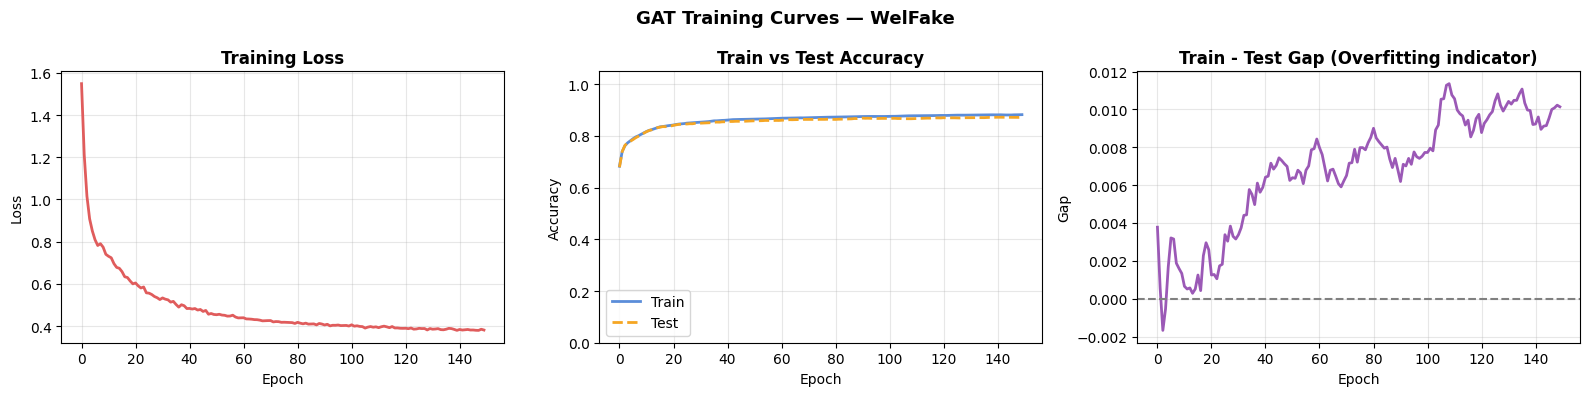

In [9]:
# ── Visualisation: Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(EPOCHS), train_losses, color='#E05C5C', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(EPOCHS), train_accs, color='#5B8DD9', linewidth=2, label='Train')
axes[1].plot(range(EPOCHS), test_accs, color='#F5A623', linewidth=2, linestyle='--', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)

gap = [tr - te for tr, te in zip(train_accs, test_accs)]
axes[2].plot(range(EPOCHS), gap, color='#9B59B6', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap')
axes[2].set_title('Train - Test Gap (Overfitting indicator)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAT Training Curves — WelFake', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Step 5 — Evaluation on WelFake Test Set

STEP 5: GAT Evaluation on WelFake Test Set

  ✅ GAT Test Accuracy on WelFake : 0.8723 (87.23%)

              precision    recall  f1-score   support

    Real (0)       0.88      0.86      0.87      4307
    Fake (1)       0.87      0.89      0.88      4493

    accuracy                           0.87      8800
   macro avg       0.87      0.87      0.87      8800
weighted avg       0.87      0.87      0.87      8800



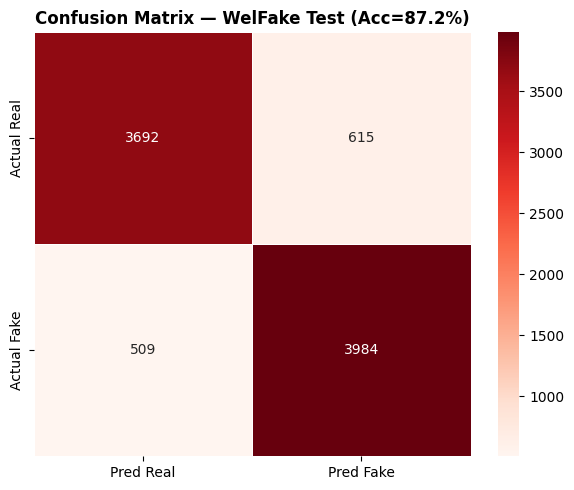

In [10]:
print('=' * 60)
print('STEP 5: GAT Evaluation on WelFake Test Set')
print('=' * 60)

model_gat.eval()
with torch.no_grad():
    out_final = model_gat(data_wf)
    pred_test = out_final[data_wf.test_mask].argmax(dim=1).cpu().numpy()
    y_test = data_wf.y[data_wf.test_mask].cpu().numpy()
    gat_wf_acc = accuracy_score(y_test, pred_test)

print(f'\n  ✅ GAT Test Accuracy on WelFake : {gat_wf_acc:.4f} ({gat_wf_acc*100:.2f}%)\n')
print(classification_report(y_test, pred_test, target_names=['Real (0)', 'Fake (1)']))

cm_wf = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_wf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — WelFake Test (Acc={gat_wf_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Step 6 — Save GAT Checkpoint

In [11]:
checkpoint_gat = {
    'model_state_dict': model_gat.state_dict(),
    'in_channels': MAX_FEATURES,
    'hidden_channels': GAT_HIDDEN,
    'out_channels': 2,
    'heads': GAT_HEADS,
    'dropout': GAT_DROPOUT,
    'test_accuracy': float(gat_wf_acc),
    'timestamp': datetime.now().isoformat(),
    'hyperparams': {
        'welfake_train_size': WELFAKE_TRAIN_SIZE,
        'fakenews_infer_size': FAKENEWS_INFER_SIZE,
        'max_features': MAX_FEATURES,
        'knn_k': KNN_K,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY
    }
}

torch.save(checkpoint_gat, CHECKPOINT_GAT)
print(f"  ✓ Saved : {CHECKPOINT_GAT}")
print(f"  ✓ Size  : {CHECKPOINT_GAT.stat().st_size/1024:.1f} KB")
print(f"  ✓ Acc   : {gat_wf_acc*100:.2f}% on WelFake test set")

  ✓ Saved : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\output\checkpoints\gat_welfake.pt
  ✓ Size  : 2008.6 KB
  ✓ Acc   : 87.23% on WelFake test set


---
## 🌐 Step 7 — Cross-dataset Inference on FakeNews (3000 samples)

STEP 7: Cross-dataset Inference on FakeNews
  ✓ FakeNews sample size: 3,000

  ✅ Accuracy on FakeNews (cross-dataset): 0.8877 (88.77%)

              precision    recall  f1-score   support

    Real (0)       0.88      0.88      0.88      1397
    Fake (1)       0.90      0.89      0.89      1603

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



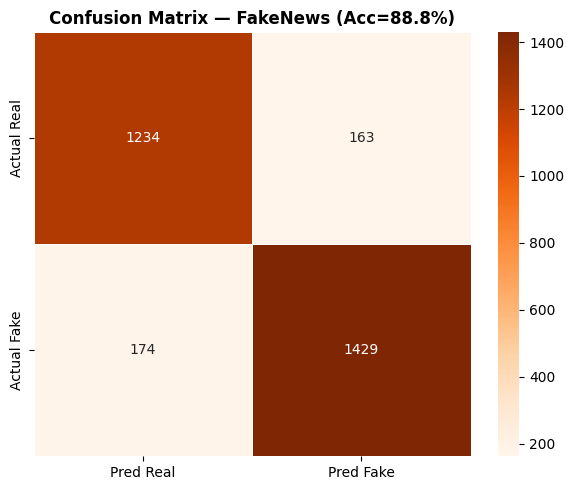

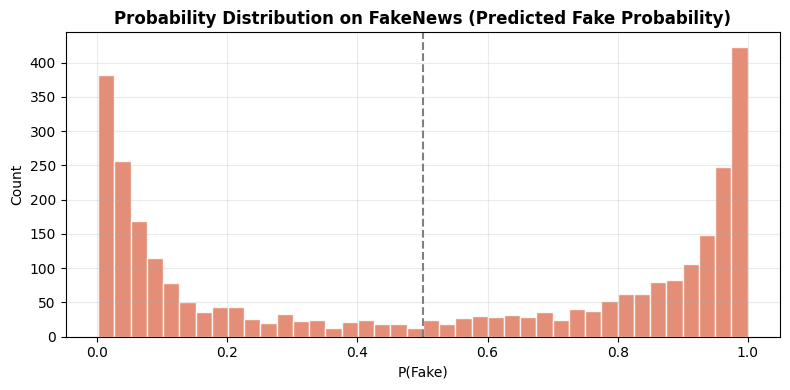

FakeNews graph nodes: 3,000
FakeNews graph edges: 21,818


In [12]:
print('=' * 60)
print('STEP 7: Cross-dataset Inference on FakeNews')
print('=' * 60)

# Load FakeNews
fake_df = pd.read_csv(FAKE_PATH)
fake_df['label'] = 1
true_df = pd.read_csv(TRUE_PATH)
true_df['label'] = 0

fn_df = pd.concat([fake_df, true_df], ignore_index=True)
fn_df = fn_df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)

fn_df['text'] = fn_df['text'].astype(str).apply(preprocess_text)
fn_df['title'] = fn_df['title'].astype(str).apply(preprocess_text)
fn_df['content'] = fn_df['title'] + ' ' + fn_df['text']
fn_df['label'] = fn_df['label'].astype(int)

fn_sample = fn_df.sample(n=min(FAKENEWS_INFER_SIZE, len(fn_df)), random_state=RANDOM_SEED).reset_index(drop=True)
y_fn = fn_sample['label'].values
print(f"  ✓ FakeNews sample size: {len(fn_sample):,}")

# Dùng vectorizer + scaler đã fit ở WelFake để giữ không gian đặc trưng
X_fn_tfidf = vectorizer.transform(fn_sample['content']).toarray()
X_fn = scaler.transform(X_fn_tfidf)

edge_index_fn, adj_fn = build_knn_graph(X_fn, KNN_K)
data_fn = Data(
    x=torch.tensor(X_fn, dtype=torch.float32).to(DEVICE),
    edge_index=edge_index_fn.to(DEVICE),
    y=torch.tensor(y_fn, dtype=torch.long).to(DEVICE)
)

model_gat.eval()
with torch.no_grad():
    fn_out = model_gat(data_fn)
    fn_probs = torch.softmax(fn_out, dim=1).cpu().numpy()
    fn_preds = fn_out.argmax(dim=1).cpu().numpy()

fn_acc = accuracy_score(y_fn, fn_preds)
print(f"\n  ✅ Accuracy on FakeNews (cross-dataset): {fn_acc:.4f} ({fn_acc*100:.2f}%)\n")
print(classification_report(y_fn, fn_preds, target_names=['Real (0)', 'Fake (1)']))

cm_fn = confusion_matrix(y_fn, fn_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — FakeNews (Acc={fn_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(fn_probs[:, 1], bins=40, color='#E07A5F', alpha=0.85, edgecolor='white')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5)
plt.xlabel('P(Fake)')
plt.ylabel('Count')
plt.title('Probability Distribution on FakeNews (Predicted Fake Probability)', fontweight='bold')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"FakeNews graph nodes: {adj_fn.shape[0]:,}")
print(f"FakeNews graph edges: {adj_fn.count_nonzero():,}")